langraph-101 is a good place to start. This notebook is to show how to set up lopcal llm using ollama. 

It is modified from https://github.com/langchain-ai/langgraph-101/blob/main/notebooks/langgraph_basics.ipynb

In [2]:
# helper function
def show_graph(graph, xray=False):
    """Display a LangGraph mermaid diagram with fallback rendering.

    Handles timeout errors from mermaid.ink by falling back to pyppeteer.

    Args:
        graph: The LangGraph object that has a get_graph() method
    """
    from IPython.display import Image
    try:
        # Try the default renderer first
        return Image(graph.get_graph(xray=xray).draw_mermaid_png())
    except Exception as e:
        # Fall back to pyppeteer if the default renderer fails
        import nest_asyncio
        nest_asyncio.apply()
        from langchain_core.runnables.graph import MermaidDrawMethod
        return Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER))

In [9]:
#https://python.langchain.com/docs/integrations/llms/ollama/
from langchain_ollama.llms import OllamaLLM
from langchain_core.messages import HumanMessage
# makesure ou start the sever: #ollama run deepseek-r1:1.5b
model = OllamaLLM(model="deepseek-r1:1.5b") # A very small model only for demo. Not good for this project

# test the LLM itself works
result = model.invoke([HumanMessage(content="What is the best book to learn LLM",name="demo")])
print(result)

<think>
Okay, so I want to learn about Large Language Models (LLMs). The user mentioned that their best recommendation was "The Art of Predictive Modeling" by N. J. Deering. But now they're asking again, and I need to explain it better.

First, I should understand what an LLM is. From what I know, LLMs are AI models designed to simulate human-level language comprehension and generation. They can generate text based on a set of instructions or context. The user probably wants to build such a model themselves or use existing ones for creative purposes like writing, storytelling, or even research.

I remember the first book recommendation was about predictive modeling with LLMs. That seems more technical and might be better for someone who has some machine learning experience. But maybe there's something simpler or more accessible that could help if they're just starting out.

I should consider different approaches: either using existing LLMs, developing one from scratch, or exploring app

In [11]:
from langchain.schema import Document
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    """
    Attributes:
        question: The user's question
        generation: The LLM's generation
        documents: List of helpful documents retrieved by the RAG pipeline
    """
    question: str
    generation: str
    documents: List[Document]

In [12]:

# implement your own function to retrieve documents.  
def retrieve_documents(state: GraphState):
    """
    A simple mock retrieval that returns documents
    based on keywords in the user's question.
    """
    question = state["question"].lower()
    if "diabetes" in question:
        documents = [
            "Gene: PDX1 — regulates insulin secretion and pancreatic beta-cell development.\n",
            "Gene: INS — encodes insulin, directly linked to glucose metabolism.\n",
            "Gene: GLP1R — receptor for GLP-1, target of incretin-based diabetes drugs.",
        ]
    elif "cancer" in question:
        documents = [
            "Gene: TP53 — tumor suppressor frequently mutated in cancers.\n",
            "Gene: AURKB (Aurora B) — regulates mitosis and is overexpressed in many tumors.\n",
            "Gene: EGFR — epidermal growth factor receptor, major target in lung cancer therapy.",
        ]
    else:
        documents = [
            "No relevant documents found. Try asking about diabetes or cancer."
        ]

    return {'documents': documents}

RAG_PROMPT = """You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use three sentences maximum and keep the answer concise.

Question: {question}
Context: {context}
Answer:
"""

def generate_response(state: GraphState):
    """
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """

    question = state["question"]
    documents = state["documents"]

    formatted_docs = '\n\n'.join(documents)

    # Invoke our LLM with our RAG prompt
    rag_prompt_formatted = RAG_PROMPT.format(context=formatted_docs, question=question)

    generation = model.invoke([HumanMessage(content=rag_prompt_formatted)])

    return {"generation": generation}



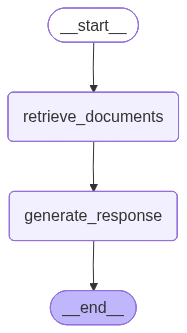

In [14]:
from langgraph.graph import StateGraph
from langgraph.graph import START, END

graph_builder = StateGraph(GraphState)

graph_builder.add_node("retrieve_documents", retrieve_documents)
graph_builder.add_node("generate_response", generate_response)


graph_builder.add_edge(START, "retrieve_documents")
graph_builder.add_edge("retrieve_documents", "generate_response")
graph_builder.add_edge("generate_response", END)

simple_rag_graph = graph_builder.compile()
show_graph(simple_rag_graph)

In [13]:
# ----- 5️⃣ Run example questions -----
for q in [
    "select a single gene as the drug target for diabetes?",
    "Tell me about genes involved in cancer.",
    "What genes affect heart disease?",
]:
    query =  {"question": q}

    result = simple_rag_graph.invoke(query)
    print('=' * 20)
    print(query)
    print('reference retrieved:')
    print(result['documents'])
    print()

    print('Model generation:',result['generation'])

{'question': 'select a single gene as the drug target for diabetes?'}
reference retrieved:
['Gene: PDX1 — regulates insulin secretion and pancreatic beta-cell development.\n', 'Gene: INS — encodes insulin, directly linked to glucose metabolism.\n', 'Gene: GLP1R — receptor for GLP-1, target of incretin-based diabetes drugs.']

Model generation: <think>
Okay, so I'm trying to figure out which gene I can use as a drug target for diabetes. The question gives me three genes: PDx1, INS, and GLP1R. Let me think about each one step by step.

First, PDx1, also known as pancreinogen A2 (PIA2), is involved in insulin secretion and the development of pancreatic beta cells. It's a big gene because it regulates fundamental diabetes genes like insulin, insulin-stimulated glucose transporters, and beta-cell development. So if I use PIAs2, it would target these specific pathways which are crucial for managing diabetes.

Next, INS encodes insulin directly. Insulin is the primary hormone that regulates b